In [ ]:
import ee
import geemap

# ========================
# 0. Initialize GEE (Google Earth Engine)
# ========================
# Note: Replace the project ID with your own GEE project ID before running
ee.Initialize(project='YOUR_GEE_PROJECT_ID')

# ========================
# 1. Get administrative boundary of Beijing
# ========================
# GAUL (Global Administrative Unit Layers) dataset - Level 1 administrative divisions of China
china_adm1 = ee.FeatureCollection("FAO/GAUL/2015/level1")

# Filter boundary by administrative name (GAUL dataset uses "Beijing Shi" for Beijing)
beijing_boundary = china_adm1.filter(
    ee.Filter.eq('ADM1_NAME', 'Beijing Shi')
).geometry()

# Define the study region
region = beijing_boundary

# ========================
# 2. Sentinel-2 data preprocessing
# ========================
def maskS2clouds(image):
    """
    Mask cloud and cirrus pixels in Sentinel-2 SR images
    Args:
        image: ee.Image - Sentinel-2 image
    Returns:
        ee.Image - Cloud-masked image with values scaled to [0,1]
    """
    qa = image.select('QA60')
    cloudBitMask = 1 << 10  # Cloud bit (10)
    cirrusBitMask = 1 << 11 # Cirrus bit (11)
    # Create mask (0 = cloud/cirrus, 1 = clear)
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(
        qa.bitwiseAnd(cirrusBitMask).eq(0)
    )
    return image.updateMask(mask).divide(10000)

# Load Sentinel-2 Surface Reflectance Harmonized dataset
s2_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate('2024-01-01', '2024-12-31') \
    .filterBounds(region) \
    .map(maskS2clouds)

# Calculate median composite to reduce temporal noise
s2_median = s2_collection.median().clip(region)

# ========================
# 3. Spectral index calculation
# ========================
# NDVI (Normalized Difference Vegetation Index)
ndvi = s2_median.normalizedDifference(['B8', 'B4']).rename('NDVI')
# NDBI (Normalized Difference Built-up Index)
ndbi = s2_median.normalizedDifference(['B11', 'B8']).rename('NDBI')
# MNDWI (Modified Normalized Difference Water Index)
mndwi = s2_median.normalizedDifference(['B3', 'B11']).rename('MNDWI')
# SWIR/NIR ratio
swir_nir_ratio = s2_median.select('B11').divide(s2_median.select('B8')).rename('SWIR_NIR')

# ========================
# 4. Texture features (GLCM - Gray Level Co-occurrence Matrix)
# ========================
# Convert NIR band (B8) to 8-bit for GLCM calculation
glcm = s2_median.select('B8').multiply(255).toUint8().glcmTexture(size=3)

# Select key texture features and rename for readability
texture_features = glcm.select([
    'B8_contrast',
    'B8_ent',
    'B8_var',
    'B8_idm',
    'B8_diss'
]).rename([
    'Contrast',
    'Entropy',
    'Variance',
    'Homogeneity',
    'Dissimilarity'
])

# ========================
# 5. Nighttime light data (VIIRS)
# ========================
# Load VIIRS monthly nighttime light dataset (2024-2025)
viirs_2024 = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate('2024-01-01', '2025-11-01') \
    .select('avg_rad') \
    .mean() \
    .clip(region) \
    .rename('Nightlight')

# ========================
# 6. Merge all features into a single image
# ========================
feature_image = ee.Image.cat([
    s2_median.select(['B2','B3','B4','B8','B11','B12']),  # Optical bands
    ndvi, ndbi, mndwi, swir_nir_ratio,                   # Spectral indices
    texture_features,                                    # Texture features
    viirs_2024                                           # Nighttime light
]).clip(region)

# Print band names for verification
print("✅ Final feature image bands:", feature_image.bandNames().getInfo())

# ========================
# 7. Visualization (for verification)
# ========================
Map = geemap.Map()
Map.addLayer(region, {'color': 'red'}, "Beijing Boundary")
Map.addLayer(feature_image, {
    'bands': ['B4','B3','B2'],
    'min': 0, 'max': 0.3
}, "Beijing Composite")
Map.centerObject(region, 8)
Map

In [21]:
# ========================
# 8. Export feature image to GEE Asset
# ========================
# Note: Replace "YOUR_GEE_PROJECT_ID" with your actual GEE project ID
task_asset = ee.batch.Export.image.toAsset(
    image=feature_image,
    description='Beijing_Feature_Image',
    assetId='projects/YOUR_GEE_PROJECT_ID/assets/Beijing_Feature_Image',
    region=region,
    scale=10,       
    maxPixels=1e13
)

task_asset.start()

# Convert image to float type for more stable export (optional but recommended)
feature_image = feature_image.toFloat()

# ========================
# 9. Export feature image to Google Drive
# ========================
# 30m scale is recommended for more stable export (10m may cause memory issues for large regions)
task_drive = ee.batch.Export.image.toDrive(
    image=feature_image,
    description='Beijing_features_toDrive',
    folder='GEE_exports',
    fileNamePrefix='Beijing_features_V1',
    scale=10,
    region=region,
    maxPixels=1e13
)

task_drive.start()

# Print export task initiation confirmation
print(" Export tasks initiated successfully. Check GEE Tasks interface for progress.")

🚀 已启动导出任务，请去 GEE Tasks 界面查看进度。


In [23]:
import ee
import geemap
import pandas as pd

# ============================
# 1. Initialize GEE (Google Earth Engine)
# ============================
try:
    # Note: Replace with your own GEE project ID and adjust opt_url if needed
    ee.Initialize(
        project='YOUR_GEE_PROJECT_ID',
        opt_url='https://earthengine-highvolume.googleapis.com'
    )
    print("✅ GEE initialized successfully")
except Exception as e:
    print(f"❌ GEE initialization failed: {e}")

# ============================
# 2. Load Beijing-related resources
# ============================
# 2.1 Beijing feature image (replace with your actual asset path)
feature_image = ee.Image('projects/YOUR_GEE_PROJECT_ID/assets/Beijing_Feature_Image_V2')  # Example asset path

# 2.2 Beijing Data Center POI (positive samples)
# Note: Replace with your local CSV file path for Beijing POI data
csv_path_positive = r"PATH/TO/YOUR/china_datacenter_wgs84 - beijing.csv"  # Example local path
try:
    poi_fc = geemap.csv_to_ee(csv_path_positive, latitude='wgs84_lat', longitude='wgs84_lon')
    positive_samples = poi_fc.map(lambda f: f.set('label', 1))
    num_positive = positive_samples.size().getInfo()
    print(f"✅ Number of positive samples (Beijing): {num_positive}")
except Exception as e:
    print(f"❌ Failed to import positive samples (Beijing): {e}")
    positive_samples = ee.FeatureCollection([])
    num_positive = 0

# 2.3 Beijing administrative boundary (GAUL dataset)
china_adm1 = ee.FeatureCollection("FAO/GAUL/2015/level1")
beijing_boundary = china_adm1.filter(ee.Filter.eq('ADM1_NAME', 'Beijing Shi')).geometry()  # Name of Beijing municipality

# 2.4 Core study area of Beijing (Haidian, Chaoyang - data center concentrated areas)
beijing_core = ee.Geometry.Rectangle([116.2, 39.8, 116.6, 40.1])  # Example: Central urban area

# ============================
# 3. Generate negative samples for Beijing
# ============================
negative_samples = ee.FeatureCollection([])
if num_positive > 0:
    print("\n🔧 Generating and filtering negative samples (Beijing)...")

    def filter_points(points, mask):
        """
        Filter random points based on spectral mask (NDVI/NDBI/Nightlight)
        Args:
            points: ee.FeatureCollection - Random points to filter
            mask: ee.Image - Binary mask image (1 = valid, 0 = invalid)
        Returns:
            ee.FeatureCollection - Filtered points with mask value attribute
        """
        return points.map(lambda f: f.set('mask_val', mask.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=f.geometry(),
            scale=30
        ).get('NDVI'))).filter(ee.Filter.eq('mask_val', 1))

    # Calculate spectral indices for masking
    ndvi = feature_image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi = feature_image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    nightlight = feature_image.select('Nightlight')

    # Loose mask (non-vegetation, built-up potential, with nightlight)
    loose_mask = ndvi.lt(0.5).And(ndbi.gt(-0.3)).And(nightlight.gt(0.05)).selfMask()
    num_candidates = num_positive * 50
    raw_points = ee.FeatureCollection.randomPoints(region=beijing_boundary, points=num_candidates, seed=42)
    filtered_points = filter_points(raw_points, loose_mask)
    filtered_count = filtered_points.size().getInfo()
    print(f"Filtered negative points (loose criteria): {filtered_count}")

    if filtered_count >= num_positive:
        negative_samples = filtered_points.randomColumn('rand', seed=42).limit(num_positive)
    else:
        print("Insufficient points with loose criteria, using backup mask...")
        # Backup mask (stricter non-vegetation, lower nightlight threshold)
        backup_mask = ndvi.lt(0.4).And(nightlight.gt(0.01)).selfMask()
        if filtered_count < num_positive * 0.5:
            raw_points = ee.FeatureCollection.randomPoints(region=beijing_boundary, points=num_positive * 100, seed=43)
        filtered_points_backup = filter_points(raw_points, backup_mask)
        filtered_backup_count = filtered_points_backup.size().getInfo()
        print(f"Filtered negative points (backup criteria): {filtered_backup_count}")
        
        if filtered_backup_count > 0:
            negative_samples = filtered_points_backup.randomColumn('rand', seed=42).limit(min(num_positive, filtered_backup_count))
        else:
            print("Warning: All filtering failed, using fully random negative samples!")
            negative_samples = raw_points.randomColumn('rand', seed=42).limit(num_positive)

    negative_samples = negative_samples.map(lambda f: f.set('label', 0))
    print(f"✅ Final negative samples (Beijing): {negative_samples.size().getInfo()}")

# ============================
# 4. Merge samples + Split train/validation sets
# ============================
all_samples = positive_samples.merge(negative_samples)
if all_samples.size().getInfo() > 1:
    all_samples_random = all_samples.randomColumn('random', seed=42)
    training_points = all_samples_random.filter(ee.Filter.lt('random', 0.7))
    validation_points = all_samples_random.filter(ee.Filter.gte('random', 0.7))
    print(f"\n📚 Training set size: {training_points.size().getInfo()}")
    print(f"📝 Validation set size: {validation_points.size().getInfo()}")
else:
    training_points = validation_points = ee.FeatureCollection([])
    print("\n⚠️  Insufficient total samples to split train/validation sets.")

# ============================
# 5. Train Random Forest classifier
# ============================
classifier = None
if training_points.size().getInfo() > 0:
    print("\n🚀 Training Random Forest classifier...")
    # Sample image values at training points
    training_data = feature_image.sampleRegions(
        collection=training_points, 
        properties=['label'], 
        scale=10, 
        tileScale=4
    )
    # Train Random Forest (200 trees) with probability output
    classifier = ee.Classifier.smileRandomForest(numberOfTrees=200, seed=42).train(
        features=training_data,
        classProperty='label'
    ).setOutputMode('PROBABILITY')
    print("✅ Classifier training completed (probability output enabled).")
else:
    print("\n⚠️  Empty training set, classifier not trained.")

# ============================
# 6. Model accuracy assessment
# ============================
if validation_points.size().getInfo() > 0 and classifier:
    # Switch classifier to classification mode for validation
    validation_classifier = classifier.setOutputMode('CLASSIFICATION')
    validation_data = feature_image.sampleRegions(collection=validation_points, properties=['label'], scale=10)
    validation_classified = validation_data.classify(validation_classifier)
    
    # Calculate confusion matrix and metrics
    cm = validation_classified.errorMatrix('label', 'classification')
    cm_info = cm.getInfo()
    print("\n📊 Model accuracy assessment results:")
    print("Confusion Matrix:", cm_info)
    print(f"Overall Accuracy: {cm.accuracy().getInfo():.4f}")
    
    # Calculate precision, recall, F1-score
    TN, FP, FN, TP = cm_info[0][0], cm_info[0][1], cm_info[1][0], cm_info[1][1]
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    print(f"Precision={precision:.4f}, Recall={recall:.4f}, F1={f1_score:.4f}")

# ============================
# 7. Extract uncertain points (Beijing)
# ============================
if classifier:
    print("\n🎯 Extracting uncertain regions and sampling (Beijing)...")
    # Generate probability image for core area
    prob_image_raw = feature_image.classify(classifier).clip(beijing_core)
    prob_image = prob_image_raw.rename('probability')
    print(f"✅ Probability image generated (Beijing), band names: {prob_image.bandNames().getInfo()}")

    # Define uncertain mask (probability 0.3-0.7)
    uncertain_mask = prob_image.select('probability').gte(0.3).And(prob_image.select('probability').lte(0.7)).selfMask()
    uncertain_points = ee.FeatureCollection.randomPoints(
        region=uncertain_mask.geometry(),
        points=100,
        seed=42,
        maxError=10
    )

    def add_wgs84_lat_lon(feature):
        """Add WGS84 latitude/longitude attributes to feature"""
        coords = feature.geometry().coordinates()
        return feature.set({
            'wgs84_lon': coords.get(0),
            'wgs84_lat': coords.get(1),
            'label': -1  # Label -1 = uncertain
        })

    def add_probability(feature):
        """Add probability value to feature from probability image"""
        prob = prob_image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=feature.geometry(),
            scale=10
        ).get('probability')
        return feature.set('probability', prob)

    # Process uncertain points (add lat/lon + probability)
    uncertain_points_with_latlon = uncertain_points.map(add_wgs84_lat_lon)
    final_samples = uncertain_points_with_latlon.map(add_probability)
    print(f"✅ Uncertain samples processed (Beijing), total points with lat/lon: {final_samples.size().getInfo()}")

    # Export uncertain samples (local path first, then Google Drive fallback)
    export_path = r"PATH/TO/YOUR/Beijing_Uncertain_Samples.csv"  # Example export path
    try:
        geemap.ee_export_vector(
            final_samples,
            filename=export_path,
            selectors=['wgs84_lon', 'wgs84_lat', 'probability', 'label']
        )
        print(f"\n🎉 Uncertain samples exported successfully (Beijing)! Path: {export_path}")
    except Exception as e:
        print(f"\n⚠️  Local export failed: {e}")
        print("   Attempting export to Google Drive...")
        task = ee.batch.Export.table.toDrive(
            collection=final_samples,
            description='Beijing_Uncertain_Samples',
            folder='GEE_Active_Learning_Samples',  # English folder name
            fileNamePrefix='Beijing_Uncertain_Samples',
            fileFormat='CSV',
            selectors=['wgs84_lon', 'wgs84_lat', 'probability', 'label']
        )
        task.start()
        print("   ✅ Google Drive export task initiated.")

# ============================
# 8. Visualize results (Beijing)
# ============================
if classifier:
    print("\n🖼️  Visualizing results (Beijing)...")
    # Generate classification image for visualization
    classified = feature_image.classify(classifier.setOutputMode('CLASSIFICATION')).clip(beijing_boundary)
    
    # Initialize map and add layers
    Map = geemap.Map()
    Map.centerObject(beijing_boundary, 8)  # Zoom level for Beijing
    Map.addLayer(
        classified, 
        {'min':0, 'max':1, 'palette':['white','red'], 'opacity':0.7}, 
        "Predicted Data Centers (Red)"
    )
    Map.addLayer(
        positive_samples.style(**{'color':'green', 'fillColor':'00ff00'}), 
        {'pointRadius':6}, 
        "True Data Centers (Green)"
    )
    if negative_samples.size().getInfo() > 0:
        Map.addLayer(negative_samples, {'color':'blue'}, "Initial Negative Samples (Blue)")
    Map.addLayerControl()
    Map

✅ GEE 初始化成功
✅ 北京正样本数量: 83

🔧 生成并过滤北京负样本...
宽松条件下过滤后得到 1673 个负样本点。
✅ 最终北京负样本数量: 83

📚 训练集数量: 119
📝 验证集数量: 47

🚀 开始训练随机森林模型...
✅ 模型训练完成（已开启概率输出）。

📊 模型精度评估结果:
混淆矩阵: [[21, 7], [1, 17]]
总体准确率: 0.8261
Precision=0.7083, Recall=0.9444, F1=0.8095

🎯 开始提取北京不确定区域并抽样...
✅ 北京概率影像生成成功，波段名: ['probability']
✅ 北京不确定样本处理完成，共 100 个带经纬度的点。
Generating URL ...
Please wait ...
Data downloaded to D:\杨紫薇\数据论文\主动学习样本\Beijing_Uncertain_Samples.csv

🎉 北京样本导出成功！路径: D:\杨紫薇\数据论文\主动学习样本\Beijing_Uncertain_Samples.csv

🖼️  可视化北京结果...


In [28]:
import ee
import geemap
import pandas as pd

# ============================
# 1. Initialize GEE (Google Earth Engine)
# ============================
try:
    # Note: Replace with your own GEE project ID before execution
    ee.Initialize(
        project='YOUR_GEE_PROJECT_ID',
        opt_url='https://earthengine-highvolume.googleapis.com'
    )
    print("✅ GEE initialized successfully")
except Exception as e:
    print(f"❌ GEE initialization failed: {e}")

# ============================
# 2. Load all samples (Core: Merge original POI + newly annotated samples)
# ============================
# 2.1 Load original POI positive samples (base positive samples)
# Note: Replace with your actual POI CSV file path
poi_csv_path = r"PATH/TO/YOUR/china_datacenter_wgs84 - beijing.csv"
try:
    original_positive = geemap.csv_to_ee(poi_csv_path, latitude='wgs84_lat', longitude='wgs84_lon')
    original_positive = original_positive.map(lambda f: f.set('label', 1))  # Label 1 = positive sample
    print(f"✅ Number of original POI positive samples: {original_positive.size().getInfo()}")
except Exception as e:
    print(f"❌ Failed to load original POI samples: {e}")
    original_positive = ee.FeatureCollection([])

# 2.2 Load newly annotated samples (1 positive + 99 negative)
# Note: Replace with your actual annotated CSV file path
annotated_csv_path = r"PATH/TO/YOUR/Beijing_Uncertain_Samples.csv"
try:
    new_annotated = geemap.csv_to_ee(annotated_csv_path, latitude='wgs84_lat', longitude='wgs84_lon')
    new_positive = new_annotated.filter(ee.Filter.eq('label', 1))
    new_negative = new_annotated.filter(ee.Filter.eq('label', 0))
    print(f"✅ New annotated samples: {new_positive.size().getInfo()} positive, {new_negative.size().getInfo()} negative")
except Exception as e:
    print(f"❌ Failed to load newly annotated samples: {e}")
    new_annotated = ee.FeatureCollection([])
    new_positive = ee.FeatureCollection([])
    new_negative = ee.FeatureCollection([])

# 2.3 Merge all samples (original positive + new positive + new negative)
all_positive = original_positive.merge(new_positive)  # All positive samples
all_negative = new_negative  # Add original negative samples here if available
all_samples = all_positive.merge(all_negative)
print(f"✅ Merged total samples: {all_positive.size().getInfo()} positive, {all_negative.size().getInfo()} negative")

# 2.4 Beijing administrative boundary + core study area
china_adm1 = ee.FeatureCollection("FAO/GAUL/2015/level1")
beijing_boundary = china_adm1.filter(ee.Filter.eq('ADM1_NAME', 'Beijing Shi')).geometry()
beijing_core = ee.Geometry.Rectangle([116.2, 39.8, 116.6, 40.1])

# ============================
# 3. Split train/validation sets (Ensure full coverage of positive samples)
# ============================
training_points = validation_points = ee.FeatureCollection([])
if all_positive.size().getInfo() > 0 and all_negative.size().getInfo() > 0:
    # Split positive samples: 80% training, 20% validation
    positive_random = all_positive.randomColumn('rand', seed=42)
    positive_train = positive_random.filter(ee.Filter.lt('rand', 0.8))
    positive_val = positive_random.filter(ee.Filter.gte('rand', 0.8))
    
    # Split negative samples: 80% training, 20% validation
    negative_random = all_negative.randomColumn('rand', seed=43)
    negative_train = negative_random.filter(ee.Filter.lt('rand', 0.8))
    negative_val = negative_random.filter(ee.Filter.gte('rand', 0.8))
    
    # Merge training/validation sets
    training_points = positive_train.merge(negative_train)
    validation_points = positive_val.merge(negative_val)
    
    print(f"\n📚 Training set size: {training_points.size().getInfo()} (including {positive_train.size().getInfo()} positive samples)")
    print(f"📝 Validation set size: {validation_points.size().getInfo()} (including {positive_val.size().getInfo()} positive samples)")
else:
    print("\n⚠️  Incomplete sample classes, cannot split train/validation sets")

# ============================
# 4. Train Random Forest classifier
# ============================
classifier = None
if training_points.size().getInfo() > 0:
    print("\n🚀 Starting classifier training...")
    # Sample image features at training points
    training_data = feature_image.sampleRegions(
        collection=training_points,
        properties=['label'],
        scale=10,
        tileScale=4
    )
    # Train Random Forest (200 trees) with probability output
    classifier = ee.Classifier.smileRandomForest(numberOfTrees=200, seed=42).train(
        features=training_data,
        classProperty='label'
    ).setOutputMode('PROBABILITY')
    print("✅ Classifier training completed!")
else:
    print("\n⚠️  Empty training set, skipping training")

# ============================
# 5. Model accuracy assessment
# ============================
if validation_points.size().getInfo() > 0 and classifier:
    print("\n📊 Model accuracy assessment:")
    # Switch to classification mode for validation
    validation_classifier = classifier.setOutputMode('CLASSIFICATION')
    validation_data = feature_image.sampleRegions(
        collection=validation_points,
        properties=['label'],
        scale=10
    )
    validation_classified = validation_data.classify(validation_classifier)
    
    # Calculate confusion matrix and overall accuracy
    cm = validation_classified.errorMatrix('label', 'classification')
    print(f"Overall Accuracy: {cm.accuracy().getInfo():.4f}")
    # Uncomment below to calculate Precision/Recall if needed
    # cm_info = cm.getInfo()
    # TN, FP, FN, TP = cm_info[0][0], cm_info[0][1], cm_info[1][0], cm_info[1][1]
    # precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    # recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    # print(f"Precision: {precision:.4f}, Recall: {recall:.4f}")

# ============================
# 6. Export next round of uncertain samples
# ============================
if classifier:
    print("\n🎯 Generating next round of uncertain samples...")
    # Generate probability image for core area
    prob_image = feature_image.classify(classifier).clip(beijing_core).rename('probability')
    # Define uncertain mask (probability between 0.3 and 0.7)
    uncertain_mask = prob_image.gte(0.3).And(prob_image.lte(0.7)).selfMask()
    
    # Generate random points in uncertain regions
    next_uncertain_points = ee.FeatureCollection.randomPoints(
        region=uncertain_mask.geometry(),
        points=100,
        seed=45,
        maxError=10
    )
    
    def add_attrs(feature):
        """
        Add WGS84 coordinates and probability value to feature
        Args:
            feature: ee.Feature - Random point feature
        Returns:
            ee.Feature - Feature with lat/lon, probability, and uncertain label (-1)
        """
        coords = feature.geometry().coordinates()
        prob = prob_image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=feature.geometry(),
            scale=10
        ).get('probability')
        return feature.set({
            'wgs84_lon': coords.get(0),
            'wgs84_lat': coords.get(1),
            'probability': prob,
            'label': -1  # Label -1 = uncertain sample
        })
    
    # Add attributes to uncertain points
    final_samples = next_uncertain_points.map(add_attrs)
    print(f"✅ Generated {final_samples.size().getInfo()} new uncertain samples")

    # Export samples (local path first, Google Drive fallback)
    # Note: Replace with your desired export path
    export_path = r"PATH/TO/YOUR/Beijing_Uncertain_Samples_V2.csv"
    try:
        geemap.ee_export_vector(
            final_samples,
            filename=export_path,
            selectors=['wgs84_lon', 'wgs84_lat', 'probability', 'label']
        )
        print(f"\n🎉 Next round samples exported successfully: {export_path}")
    except Exception as e:
        print(f"\n⚠️  Local export failed, attempting Google Drive export...")
        task = ee.batch.Export.table.toDrive(
            collection=final_samples,
            description='Beijing_Uncertain_Samples_V3',
            folder='GEE_Active_Learning_Samples',  # English folder name
            fileNamePrefix='Beijing_Uncertain_Samples_V3',
            fileFormat='CSV'
        )
        task.start()
        print("   ✅ Google Drive export task initiated")

✅ GEE 初始化成功
✅ 原始POI正样本数量: 83
✅ 新标注样本：1个正样本，99个负样本
✅ 合并后总样本：84个正样本，99个负样本

📚 训练集数量: 150（含70个正样本）
📝 验证集数量: 33（含14个正样本）

🚀 开始训练模型...
✅ 模型训练完成！

📊 模型精度评估:
总体准确率: 0.7576

🎯 生成下一轮不确定样本...
✅ 生成100个新样本
Generating URL ...
Please wait ...
Data downloaded to D:\杨紫薇\数据论文\主动学习样本\Beijing_Uncertain_Samples_V2.csv

🎉 下一轮样本已导出：D:\杨紫薇\数据论文\主动学习样本\Beijing_Uncertain_Samples_V2.csv


In [37]:
china_adm1 = ee.FeatureCollection("FAO/GAUL/2015/level1")
Guangdong_boundary = china_adm1.filter(
    ee.Filter.eq('ADM1_NAME', 'Beijing Shi')
).geometry()

region = Beijing_boundary

classified = feature_image.classify(classifier).clip(region)
task_drive = ee.batch.Export.image.toDrive(
    image=classified,
    description='Beijing_Classification_toDrive',
    folder='GEE_exports',
    fileNamePrefix='Beijing_Classification',
    scale=10,
    region=region,
    maxPixels=1e13
)
task_drive.start()

🚀 导出结果到 Google drive，任务已启动。


In [33]:
import ee
import geemap
import pandas as pd

# ============================
# 1. Initialize GEE (Google Earth Engine)
# ============================
try:
    # Note: Replace with your own GEE project ID before execution
    ee.Initialize(
        project='YOUR_GEE_PROJECT_ID',
        opt_url='https://earthengine-highvolume.googleapis.com'
    )
    print("✅ GEE initialized successfully")
except Exception as e:
    print(f"❌ GEE initialization failed: {e}")

# ============================
# 2. Load all historical samples (Core: Cumulative merge)
# ============================
# 2.1 Original POI positive samples (base dataset)
# Note: Replace with your actual POI CSV file path
poi_csv_path = r"PATH/TO/YOUR/china_datacenter_wgs84 - beijing.csv"
try:
    original_positive = geemap.csv_to_ee(poi_csv_path, latitude='wgs84_lat', longitude='wgs84_lon')
    original_positive = original_positive.map(lambda f: f.set('label', 1))  # Label 1 = positive sample
    print(f"✅ Original POI positive samples: {original_positive.size().getInfo()}")
except Exception as e:
    print(f"❌ Failed to load original POI samples: {e}")
    original_positive = ee.FeatureCollection([])

# 2.2 Round 1 annotated samples (V1: 1 positive + 99 negative)
# Note: Replace with your actual Round 1 CSV file path
v1_csv_path = r"PATH/TO/YOUR/Beijing_Uncertain_Samples.csv"
try:
    v1_samples = geemap.csv_to_ee(v1_csv_path, latitude='wgs84_lat', longitude='wgs84_lon')
    v1_positive = v1_samples.filter(ee.Filter.eq('label', 1))
    v1_negative = v1_samples.filter(ee.Filter.eq('label', 0))
    print(f"✅ Round 1 annotated samples: {v1_positive.size().getInfo()} positive, {v1_negative.size().getInfo()} negative")
except Exception as e:
    print(f"❌ Failed to load Round 1 samples: {e}")
    v1_samples = ee.FeatureCollection([])
    v1_positive = ee.FeatureCollection([])
    v1_negative = ee.FeatureCollection([])

# 2.3 Round 2 annotated samples (V2: All negative)
# Note: Replace with your actual Round 2 CSV file path
v2_csv_path = r"PATH/TO/YOUR/Beijing_Uncertain_Samples_V2.csv"
try:
    v2_samples = geemap.csv_to_ee(v2_csv_path, latitude='wgs84_lat', longitude='wgs84_lon')
    v2_negative = v2_samples.filter(ee.Filter.eq('label', 0))
    print(f"✅ Round 2 annotated samples: {v2_negative.size().getInfo()} negative (all label 0)")
except Exception as e:
    print(f"❌ Failed to load Round 2 samples: {e}")
    v2_samples = ee.FeatureCollection([])
    v2_negative = ee.FeatureCollection([])

# 2.4 Merge all samples
all_positive = original_positive.merge(v1_positive)
all_negative = v1_negative.merge(v2_negative)
all_training_samples = all_positive.merge(all_negative)
print(f"\n✅ Merged total training set: {all_positive.size().getInfo()} positive, {all_negative.size().getInfo()} negative")

# 2.5 Beijing region information
china_adm1 = ee.FeatureCollection("FAO/GAUL/2015/level1")
beijing_boundary = china_adm1.filter(ee.Filter.eq('ADM1_NAME', 'Beijing Shi')).geometry()
beijing_core = ee.Geometry.Rectangle([116.2, 39.8, 116.6, 40.1])

# ============================
# 3. Split train/validation sets
# ============================
training_points = validation_points = ee.FeatureCollection([])
if all_positive.size().getInfo() > 0 and all_negative.size().getInfo() > 0:
    # Split positive samples: 80% training, 20% validation
    positive_random = all_positive.randomColumn('rand', seed=44)
    positive_train = positive_random.filter(ee.Filter.lt('rand', 0.8))
    positive_val = positive_random.filter(ee.Filter.gte('rand', 0.8))
    
    # Split negative samples: 80% training, 20% validation
    negative_random = all_negative.randomColumn('rand', seed=45)
    negative_train = negative_random.filter(ee.Filter.lt('rand', 0.8))
    negative_val = negative_random.filter(ee.Filter.gte('rand', 0.8))
    
    # Merge training/validation sets
    training_points = positive_train.merge(negative_train)
    validation_points = positive_val.merge(negative_val)
    
    print(f"\n📚 Training set: {training_points.size().getInfo()} samples (including {positive_train.size().getInfo()} positive)")
    print(f"📝 Validation set: {validation_points.size().getInfo()} samples (including {positive_val.size().getInfo()} positive)")
else:
    print("\n⚠️  Incomplete sample classes, cannot split train/validation sets")

# ============================
# 4. Train Round 3 Random Forest classifier
# ============================
classifier = None
if training_points.size().getInfo() > 0:
    print("\n🚀 Starting Round 3 classifier training...")
    # Sample image features at training points
    training_data = feature_image.sampleRegions(
        collection=training_points,
        properties=['label'],
        scale=10,
        tileScale=4
    )
    # Train Random Forest (200 trees) with probability output
    classifier = ee.Classifier.smileRandomForest(numberOfTrees=200, seed=46).train(
        features=training_data,
        classProperty='label'
    ).setOutputMode('PROBABILITY')
    print("✅ Round 3 classifier training completed!")
else:
    print("\n⚠️  Empty training set, cannot train classifier")

# ============================
# 5. Model accuracy assessment (Syntax error fixed)
# ============================
if validation_points.size().getInfo() > 0 and classifier:
    print("\n📊 Round 3 model accuracy assessment:")
    # Switch to classification mode for validation
    validation_classifier = classifier.setOutputMode('CLASSIFICATION')
    validation_data = feature_image.sampleRegions(
        collection=validation_points,
        properties=['label'],
        scale=10
    )
    validation_classified = validation_data.classify(validation_classifier)
    cm = validation_classified.errorMatrix('label', 'classification')
    print(f"Overall Accuracy: {cm.accuracy().getInfo():.4f}")
    
    # --- Fixed section start ---
    precision = recall = f1 = 0  # Initialize metrics
    try:
        # Retrieve confusion matrix from GEE server to local Python environment
        cm_array = cm.getInfo()
        
        # Extract TP, TN, FP, FN from 2D confusion matrix array
        # Confusion matrix structure: [[TN, FP], [FN, TP]]
        TN = cm_array[0][0]
        FP = cm_array[0][1]
        FN = cm_array[1][0]
        TP = cm_array[1][1]
        
        # Calculate key evaluation metrics
        if (TP + FP) > 0:
            precision = TP / (TP + FP)  # Precision = True Positive / (True Positive + False Positive)
        if (TP + FN) > 0:
            recall = TP / (TP + FN)     # Recall = True Positive / (True Positive + False Negative)
        if (precision + recall) > 0:
            f1 = 2 * precision * recall / (precision + recall)  # F1 Score = 2*(Precision*Recall)/(Precision+Recall)
        
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")

    except IndexError:
        print("⚠️  Cannot calculate detailed metrics. Reason: Abnormal confusion matrix dimension (one class may have 0 samples in validation set).")
    # --- Fixed section end ---

# ============================
# 6. Export Round 3 uncertain samples for annotation
# ============================
if classifier:
    print("\n🎯 Generating Round 3 uncertain samples (probability 0.3-0.7)...")
    # Generate probability image for core area
    prob_image = feature_image.classify(classifier).clip(beijing_core).rename('probability')
    # Define uncertain mask (probability between 0.3 and 0.7)
    uncertain_mask = prob_image.gte(0.3).And(prob_image.lte(0.7)).selfMask()
    
    # Generate random points in uncertain regions
    next_uncertain_points = ee.FeatureCollection.randomPoints(
        region=uncertain_mask.geometry(),
        points=100,
        seed=47,
        maxError=10
    )
    
    def add_sample_attrs(feature):
        """
        Add WGS84 coordinates and probability value to uncertain sample points
        Args:
            feature: ee.Feature - Random point feature in uncertain region
        Returns:
            ee.Feature - Feature with lat/lon, probability, and uncertain label (-1)
        """
        coords = feature.geometry().coordinates()
        point_prob = prob_image.reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=feature.geometry(),
            scale=10
        ).get('probability')
        return feature.set({
            'wgs84_lon': coords.get(0),
            'wgs84_lat': coords.get(1),
            'probability': point_prob,
            'label': -1  # Label -1 = uncertain sample (to be annotated)
        })
    
    # Add attributes to uncertain points
    final_uncertain_samples = next_uncertain_points.map(add_sample_attrs)
    print(f"✅ Generated {final_uncertain_samples.size().getInfo()} Round 3 uncertain samples for annotation")

    # Note: Replace with your desired export path
    export_path = r"PATH/TO/YOUR/Beijing_Uncertain_Samples_V3.csv"
    try:
        geemap.ee_export_vector(
            final_uncertain_samples,
            filename=export_path,
            selectors=['wgs84_lon', 'wgs84_lat', 'probability', 'label']
        )
        print(f"\n🎉 Round 3 uncertain samples exported successfully: {export_path}")
    except Exception as e:
        print(f"\n⚠️  Local export failed, attempting Google Drive export...")
        task = ee.batch.Export.table.toDrive(
            collection=final_uncertain_samples,
            description='Beijing_Uncertain_Samples_V3',
            folder='GEE_Active_Learning_Samples',  # English folder name
            fileNamePrefix='Beijing_Uncertain_Samples_V3',
            fileFormat='CSV',
            selectors=['wgs84_lon', 'wgs84_lat', 'probability', 'label']
        )
        task.start()
        print("   ✅ Google Drive export task initiated")

# ============================
# 7. Visualization of prediction results
# ============================
if classifier:
    print("\n🖼️  Visualizing Round 3 model prediction results...")
    # Generate classification image for visualization
    classified_image = feature_image.classify(classifier.setOutputMode('CLASSIFICATION')).clip(beijing_boundary)
    
    # Initialize map and add layers
    Map = geemap.Map()
    Map.centerObject(beijing_boundary, 9)
    Map.addLayer(
        classified_image, 
        {'min': 0, 'max': 1, 'palette': ['white', 'red'], 'opacity': 0.6}, 
        "Predicted Results (Red = Data Centers)"
    )
    Map.addLayer(all_positive, {'color': 'green'}, "All Known Positive Samples")
    Map.addLayer(final_uncertain_samples, {'color': 'blue'}, "Round 3 Uncertain Samples (To Annotate)")
    Map.addLayerControl()
    Map

✅ GEE 初始化成功
✅ 原始POI正样本：83个
✅ 第一轮标注样本：1个正，99个负
✅ 第二轮标注样本：100个负（全为0）

✅ 合并后总训练集：84个正，199个负

📚 训练集：217个（含69个正）
📝 验证集：66个（含15个正）

🚀 开始训练第三轮模型...
✅ 第三轮模型训练完成！

📊 第三轮模型精度评估：
总体准确率: 0.8485
精确率 (Precision): 0.6923
召回率 (Recall): 0.6000
F1分数: 0.6429

🎯 生成第三轮不确定样本（0.3-0.7概率区间）...
✅ 生成100个第三轮待标注样本
Generating URL ...
Please wait ...
Data downloaded to D:\杨紫薇\数据论文\主动学习样本\Beijing_Uncertain_Samples_V3.csv

🎉 第三轮待标注样本已导出：D:\杨紫薇\数据论文\主动学习样本\Beijing_Uncertain_Samples_V3.csv

🖼️  可视化第三轮模型预测结果...


In [34]:
import ee
import geemap
import pandas as pd

ee.Initialize(project='')

csv_path = r"D:\china_datacenter_clean - beijing.csv"
poi_fc = geemap.csv_to_ee(csv_path, latitude='latitude', longitude='longitude')

positive_samples = poi_fc.map(lambda f: f.set('label', 1))
print("✅ Positive samples:", positive_samples.size().getInfo())


✅ 正样本数量: 83


In [7]:
import ee
import geemap
import pandas as pd

# ============================
# Initialize GEE (Google Earth Engine)
# ============================
# Note: Replace with your own GEE project ID before execution
try:
    ee.Initialize(project='YOUR_GEE_PROJECT_ID')
    print("✅ GEE initialized successfully")
except Exception as e:
    print(f"❌ GEE initialization failed: {e}")

# ============================
# 1. Load feature image (preprocessed Sentinel-2 + indices + texture + nightlight)
# ============================
# Note: Replace with your actual GEE Asset path
feature_image = ee.Image('projects/YOUR_GEE_PROJECT_ID/assets/Beijing_Feature_Image_V1')

# ============================
# 2. Import positive samples (Data Center POI CSV)
# ============================
# Note: Replace with your local CSV file path for Beijing data center POIs
csv_path = r"PATH/TO/YOUR/china_datacenter_clean - beijing.csv"

try:
    # Convert CSV to EE FeatureCollection (latitude/longitude columns)
    poi_fc = geemap.csv_to_ee(csv_path, latitude='latitude', longitude='longitude')
    # Label 1 = positive sample (data center)
    positive_samples = poi_fc.map(lambda f: f.set('label', 1))
    print(f"✅ Number of positive samples: {positive_samples.size().getInfo()}")
except Exception as e:
    print(f"❌ Failed to import positive samples: {e}")
    positive_samples = ee.FeatureCollection([])

# ============================
# 3. Generate random negative samples
# ============================
# Get Beijing administrative boundary (GAUL Level 1 dataset)
china_adm1 = ee.FeatureCollection("FAO/GAUL/2015/level1")
beijing_boundary = china_adm1.filter(ee.Filter.eq('ADM1_NAME', 'Beijing Shi')).geometry()

# Generate 1000 random negative samples (label 0 = non-data center)
negative_points = ee.FeatureCollection.randomPoints(beijing_boundary, 1000, seed=42)
negative_samples = negative_points.map(lambda f: f.set('label', 0))
print(f"✅ Number of negative samples: {negative_samples.size().getInfo()}")

# ============================
# 4. Merge samples and extract image features
# ============================
if positive_samples.size().getInfo() > 0:
    training_points = positive_samples.merge(negative_samples)
    
    # Sample image features at sample points (10m scale, keep geometries)
    training_data = feature_image.sampleRegions(
        collection=training_points,
        properties=['label'],
        scale=10,
        geometries=True
    )
    print(f"✅ Training data generated: {training_data.size().getInfo()} samples")
else:
    training_data = ee.FeatureCollection([])
    print("⚠️  No positive samples available, cannot create training data")

# ============================
# 5. Train Random Forest classifier
# ============================
classifier = None
if training_data.size().getInfo() > 0:
    # Train Random Forest classifier (100 trees)
    classifier = ee.Classifier.smileRandomForest(numberOfTrees=100).train(
        features=training_data,
        classProperty='label'
    )
    print("✅ Random Forest classifier training completed")
else:
    print("⚠️  Empty training data, cannot train classifier")

# ============================
# 6. Generate classification result
# ============================
classified = None
if classifier:
    # Classify feature image and clip to Beijing boundary
    classified = feature_image.classify(classifier).clip(beijing_boundary)
    print("✅ Classification image generated (Beijing)")

# ============================
# 7. Model validation (Confusion Matrix + Overall Accuracy)
# ============================
if classifier and training_data.size().getInfo() > 0:
    # Classify training data for validation
    validation = training_data.classify(classifier)
    # Calculate confusion matrix and accuracy
    cm = validation.errorMatrix('label', 'classification')
    print('\n📊 Model Validation Results:')
    print('Confusion Matrix:')
    print(cm.getInfo())
    print(f'Overall Accuracy: {cm.accuracy().getInfo():.4f}')

# ============================
# 8. Visualize classification results
# ============================
if classified:
    Map = geemap.Map()
    Map.centerObject(beijing_boundary, 8)
    Map.addLayer(beijing_boundary, {'color': 'red'}, "Beijing Boundary")
    Map.addLayer(
        classified, 
        {'min': 0, 'max': 1, 'palette': ['white', 'red']}, 
        "Predicted Data Centers (Red)"
    )
    Map

✅ 正样本数量: 83
混淆矩阵:
[[1000, 0], [4, 78]]
总体准确率: 0.9963031423290203


Map(center=[40.18881570028635, 116.39396342630138], controls=(WidgetControl(options=['position', 'transparent_…

In [12]:

classified = feature_image.classify(classifier).clip(beijing_boundary)

Map = geemap.Map()
Map.centerObject(beijing_boundary, 8)
Map.addLayer(beijing_boundary, {'color':'red'}, "Beijing Boundary")
Map.addLayer(classified, {'min':0, 'max':1, 'palette':['white','red']}, "Predicted Data Centers")
Map


task = ee.batch.Export.image.toAsset(
    image=classified,
    description='Beijing_Classification_RF_V2',
    assetId='projects/protean-fabric-/assets/Beijing_Classification_RF',
    region=beijing_boundary,
    scale=10,           # Sentinel-2 分辨率
    maxPixels=1e13
)
task.start()



🚀 导出分类结果到 GEE Asset，任务已启动。


In [5]:

cm = validation_classified.errorMatrix('label', 'classification')
cm_info = cm.getInfo() 

print("confusion matrix:")
print(cm_info)
accuracy = cm.accuracy().getInfo()
print("confusion matrix:", accuracy)


TN = cm_info[0][0]
FP = cm_info[0][1]
FN = cm_info[1][0]
TP = cm_info[1][1]


precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1_score)


混淆矩阵:
[[19, 2], [3, 21]]
总体准确率: 0.8888888888888888
精确率 (Precision): 0.9130434782608695
召回率 (Recall): 0.875
F1-score: 0.8936170212765957


In [9]:
china_adm1 = ee.FeatureCollection("FAO/GAUL/2015/level1")
Beijing_boundary = china_adm1.filter(
    ee.Filter.eq('ADM1_NAME', 'Beijing Shi')
).geometry()

region = Beijing_boundary

classified = feature_image.classify(classifier).clip(region)
task_drive = ee.batch.Export.image.toDrive(
    image=classified,
    description='Beijing_Classification_toDrive',
    folder='GEE_exports',
    fileNamePrefix='Beijing_Classification',
    scale=10,
    region=region,
    maxPixels=1e13
)
task_drive.start()


🚀 导出结果到 Google drive，任务已启动。


In [12]:
import ee
ee.Initialize(project='')

img = ee.Image('projects/protean-fabric/assets/Beijing_Classification_RF')
bc = ee.FeatureCollection("FAO/GAUL/2015/level1").filter(ee.Filter.eq('ADM1_NAME','Beijing Shi'))
print(img.bandNames().getInfo())
print("minMax:", img.reduceRegion(ee.Reducer.minMax(), bc.geometry(), scale=30, bestEffort=True).getInfo())
print("hist:", img.reduceRegion(ee.Reducer.frequencyHistogram(), bc.geometry(), scale=30, bestEffort=True).getInfo())


['classification']
minMax: {'classification_max': 1, 'classification_min': 0}
hist: {'classification': {'0': 8183246.674509802, '1': 1814940.337254902}}


In [13]:

importance_dict = ee.Dictionary(classifier.explain().get('importance'))

print(importance_dict.getInfo())

import pandas as pd
import matplotlib.pyplot as plt


importance = importance_dict.getInfo()
importance_df = pd.DataFrame(list(importance.items()), columns=['Feature', 'Importance'])
importance_df = importance_df.sort_values('Importance', ascending=False)


print(importance_df)

📊 特征重要性 (GEE端)：
{'B11': 13.867453853201257, 'B12': 11.345331068985029, 'B2': 15.969886737855722, 'B3': 15.992351453248059, 'B4': 14.360031092803512, 'B8': 12.130422216481547, 'Contrast': 11.271692034796853, 'Dissimilarity': 16.55734588924151, 'Entropy': 14.427927344565774, 'Homogeneity': 16.362152912714116, 'MNDWI': 19.324795372738045, 'NDBI': 9.596946847150607, 'NDVI': 13.70704175829922, 'Nightlight': 32.08275987282146, 'SWIR_NIR': 13.764540663740902, 'Variance': 12.469627869017321}
          Feature  Importance
13     Nightlight   32.082760
10          MNDWI   19.324795
7   Dissimilarity   16.557346
9     Homogeneity   16.362153
3              B3   15.992351
2              B2   15.969887
8         Entropy   14.427927
4              B4   14.360031
0             B11   13.867454
14       SWIR_NIR   13.764541
12           NDVI   13.707042
15       Variance   12.469628
5              B8   12.130422
1             B12   11.345331
6        Contrast   11.271692
11           NDBI    9.596947


In [14]:

importance_df.to_csv(r"D:\Feature_importance\Beijing_feature_importance.csv", index=False)


csv文件已导出完成！


In [15]:

validation_pred = validation_data.classify(classifier)


task = ee.batch.Export.table.toDrive(
    collection=validation_pred,
    description='Beijing_RF_ValidationResults',
    folder='GEE_exports',
    fileNamePrefix='Beijing_RF_validation',
    fileFormat='CSV'
)
task.start()



🚀 ROC验证数据导出任务已启动，请到 GEE Tasks 查看进度。


✅ 图像已保存至：D:\杨紫薇\数据论文\Figure\BeijingROCcurve.jpeg


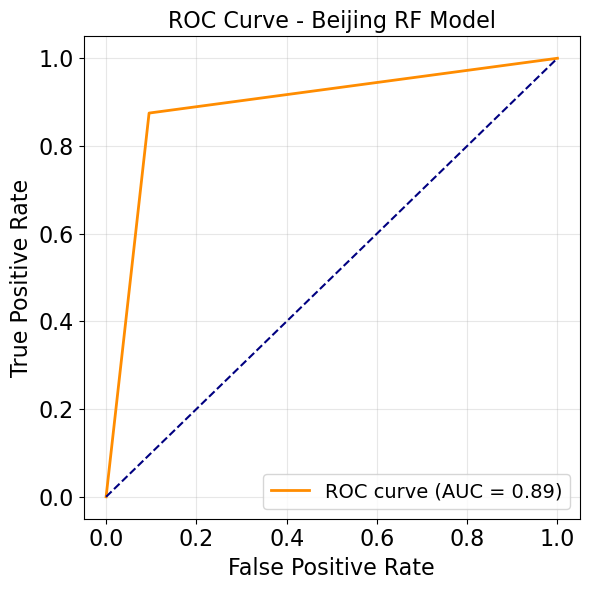

In [35]:
import pandas as pd
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


df = pd.read_csv(r"D:\Google download\Beijing_RF_validation.csv")


y_true = df["label"]
y_pred = df["classification"]

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)


plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='navy', lw=1.5, linestyle='--')
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
 
plt.xticks(fontsize=16) 
plt.yticks(fontsize=16)  

plt.title('ROC Curve - Beijing RF Model', fontsize=16)
plt.legend(loc="lower right",fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()



save_path = r"D:\Figure\BeijingROCcurve.jpeg"
plt.savefig(
    save_path,
    dpi=600, 
    bbox_inches='tight'  
)
plt.show()